In [171]:
import numpy as np
import pandas as pd
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns

In [172]:
def load_file(filepath):
    dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
    return dataframe.values

In [173]:
# load a list of files and return as a 3d numpy array
def load_group(filenames, prefix=''):
    loaded = list()
    for name in filenames:
        data = load_file(prefix + name)
        loaded.append(data)
    # stack group so that features are the 3rd dimension
    loaded = np.dstack(loaded)
    return loaded

In [174]:
# load a dataset group, such as train or test
def load_dataset_group(group, prefix=''):
    filepath = prefix + group + '/Inertial Signals/'
    # load all 9 files as a single array
    filenames = list()
    # total acceleration
    filenames += ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt']
    # body acceleration
    filenames += ['body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt']
    # body gyroscope
    filenames += ['body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
    # load input data
    X = load_group(filenames, filepath)
    # load class output
    y = load_file(prefix + group + '/y_'+group+'.txt')
    return X, y

In [175]:
# load the dataset, returns train and test X and y elements
def load_dataset(prefix=''):
    # load all train
    trainX, trainy = load_dataset_group('train', prefix + '/content/drive/MyDrive/Colab Notebooks/UCI HAR Dataset/')
    # load all test
    testX, testy = load_dataset_group('test', prefix + '/content/drive/MyDrive/Colab Notebooks/UCI HAR Dataset/')

    #zero-offset class values
    trainy = trainy - 1
    testy = testy - 1
    #one hot encode y
    trainy_one_hot = to_categorical(trainy)
    testy_one_hot = to_categorical(testy)
    print(trainX.shape, trainy.shape, trainy_one_hot.shape, testX.shape, testy.shape, testy_one_hot.shape)
    return trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot

In [176]:
trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot = load_dataset()

from sklearn.model_selection import train_test_split

X_train,X_val,y_train_one_hot,y_val_one_hot,y_train,y_val=train_test_split(trainX, trainy_one_hot, trainy,test_size=0.2,random_state=100)

X_train.shape,X_val.shape,y_train_one_hot.shape,y_val_one_hot.shape,y_train.shape,y_val.shape

/tmp/ipython-input-1098839523.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-1098839523.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-1098839523.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-1098839523.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)


(7352, 128, 9) (7352, 1) (7352, 6) (2947, 128, 9) (2947, 1) (2947, 6)


/tmp/ipython-input-1098839523.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-1098839523.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)


((5881, 128, 9), (1471, 128, 9), (5881, 6), (1471, 6), (5881, 1), (1471, 1))

In [177]:
n_timesteps, n_features, n_outputs = X_train.shape[1], X_train.shape[2], y_train_one_hot.shape[1]

In [178]:
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Dense, Flatten, Dropout,
    Conv1D, MaxPooling1D, LSTM, concatenate
)
from tensorflow.keras.utils import to_categorical

##Level_1
# layer 1
inputs1_1= Input(shape=(n_timesteps,n_features))##128,9
conv1_1 = Conv1D(filters=128, kernel_size=3, activation='relu')(inputs1_1) ##none,126,128
# layer 2
inputs1_2= Input(shape=(n_timesteps,n_features))
conv1_2 = Conv1D(filters=128, kernel_size=5, activation='relu')(inputs1_2)##124,128
# layer 3
inputs1_3= Input(shape=(n_timesteps,n_features))
conv1_3 = Conv1D(filters=128, kernel_size=7, activation='relu')(inputs1_3)##122,128
# layer 4
inputs1_4= Input(shape=(n_timesteps,n_features))
conv1_4 = Conv1D(filters=128, kernel_size=9, activation='relu')(inputs1_4)##120,128

# merge1
merged_1 = concatenate([conv1_1,conv1_2,conv1_3,conv1_4],axis=1)

#maxpool1
pool_1=MaxPooling1D(pool_size=5)(merged_1)

##Level_2
# layer 1
conv2_1 = Conv1D(filters=64, kernel_size=3, activation='relu')(pool_1)
# layer 2
conv2_2 = Conv1D(filters=64, kernel_size=5, activation='relu')(pool_1)
# layer 3
conv2_3 = Conv1D(filters=64, kernel_size=7, activation='relu')(pool_1)
# layer 4

conv2_4 = Conv1D(filters=64, kernel_size=9, activation='relu')(pool_1)
# merge2
merged_2 = concatenate([conv2_1,conv2_2,conv2_3,conv2_4],axis=1)

#maxpool2
pool_2=MaxPooling1D(pool_size=5)(merged_2)


##Level_3
# layer 1
conv3_1 = Conv1D(filters=32, kernel_size=3, activation='relu')(pool_2)
# layer 2
conv3_2 = Conv1D(filters=32, kernel_size=5, activation='relu')(pool_2)
# layer 3
conv3_3 = Conv1D(filters=32, kernel_size=7, activation='relu')(pool_2)
# layer 4

conv3_4 = Conv1D(filters=32, kernel_size=9, activation='relu')(pool_2)
# merge2
merged_3 = concatenate([conv3_1,conv3_2,conv3_3,conv3_4],axis=1)

#maxpool2
pool_3=MaxPooling1D(pool_size=5)(merged_3)


#flatten
flat_cnn=Flatten()(pool_3)

##dense layer
dense = Dense(512, activation='relu')(flat_cnn)
outputs = Dense(n_outputs, activation='softmax')(dense)

##MODEL
cnn3_model = Model([inputs1_1, inputs1_2, inputs1_3,inputs1_4], outputs)

cnn3_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
cnn3_model.summary()

Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_50      │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_51      │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_52      │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_53      │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_135 (Conv1D) │ (None, 126, 128)  │      3,584 │ input_layer_50[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_136 (Conv1D) │ (None, 124, 128)  │      5,888 │ input_layer_51[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_137 (Conv1D) │ (None, 122, 128)  │      8,192 │ input_layer_52[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_138 (Conv1D) │ (None, 120, 128)  │     10,496 │ input_layer_53[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 492, 128)  │          0 │ conv1d_135[0][0], │
│ (Concatenate)       │                   │            │ conv1d_136[0][0], │
│                     │                   │            │ conv1d_137[0][0], │
│                     │                   │            │ conv1d_138[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_20    │ (None, 98, 128)   │          0 │ concatenate_10[0… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_139 (Conv1D) │ (None, 96, 64)    │     24,640 │ max_pooling1d_20… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_140 (Conv1D) │ (None, 94, 64)    │     41,024 │ max_pooling1d_20… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_141 (Conv1D) │ (None, 92, 64)    │     57,408 │ max_pooling1d_20… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_142 (Conv1D) │ (None, 90, 64)    │     73,792 │ max_pooling1d_20… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_11      │ (None, 372, 64)   │          0 │ conv1d_139[0][0], │
│ (Concatenate)       │                   │            │ conv1d_140[0][0], │
│                     │                   │            │ conv1d_141[0][0], │
│                     │                   │            │ conv1d_142[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_21    │ (None, 74, 64)    │          0 │ concatenate_11[0… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_143 (Conv1D) │ (None, 72, 32)    │      6,176 │ max_pooling1d_21… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_144 (Conv1D) │ (None, 70, 32)    │     10,272 │ max_pooling1d_21… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_145 (Conv1D) │ (None, 68, 32)    │     14,368 │ max_pooling1d_21

 Total params: 1,179,014 (4.50 MB)

 Trainable params: 1,179,014 (4.50 MB)

 Non-trainable params: 0 (0.00 B)

In [179]:
model_history=cnn3_model.fit(x=[X_train,X_train,X_train,X_train], y=y_train_one_hot, epochs=30, batch_size=32,validation_split=0.1)

Epoch 1/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.7644 - loss: 0.5847 - val_accuracy: 0.9525 - val_loss: 0.1231
Epoch 2/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9475 - loss: 0.1325 - val_accuracy: 0.9440 - val_loss: 0.1333
Epoch 3/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9464 - loss: 0.1327 - val_accuracy: 0.9559 - val_loss: 0.0991
Epoch 4/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9524 - loss: 0.1166 - val_accuracy: 0.9542 - val_loss: 0.1078
Epoch 5/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9524 - loss: 0.1130 - val_accuracy: 0.9542 - val_loss: 0.0999
Epoch 6/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9637 - loss: 0.0947 - val_accuracy: 0.9593 - val_loss: 0.0980
Epoch 7/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9567 - loss: 0.0964 - val_accuracy: 0.9440 - val_loss: 0.1377
Epoch 8/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9533 - loss: 0.1238 - val_accuracy: 

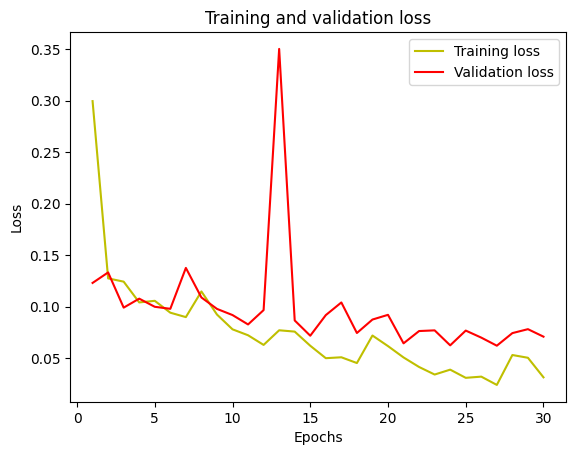

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

loss =model_history.history['loss']
val_loss =model_history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


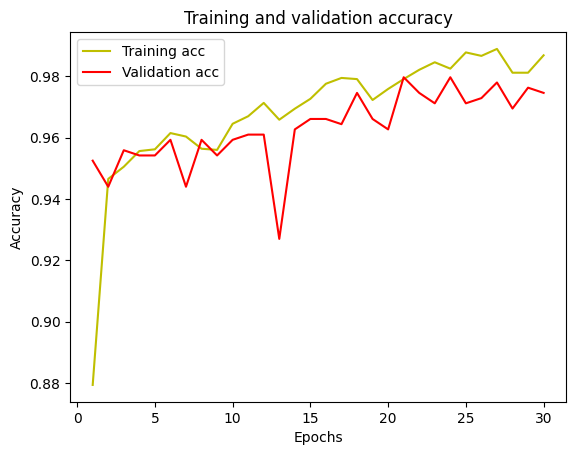

In [181]:
acc =model_history.history['accuracy']
val_acc =model_history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [182]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D,
    GlobalAveragePooling1D, Dense
)
#1 CNN
##Level_1
# layer 1
inputs= Input(shape=(n_timesteps,n_features))##128,9
x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inputs)
x = MaxPooling1D(pool_size=2)(x)
x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
x = GlobalAveragePooling1D()(x)

# 완전 연결층
x = Dense(64, activation='relu')(x)
outputs = Dense(n_outputs, activation='softmax')(x)


# 모델 정의
cnn_model = Model(inputs, outputs)

# 컴파일
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 모델 요약 출력
cnn_model.summary()

Model: "functional_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_54 (InputLayer)     │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_147 (Conv1D)             │ (None, 128, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_23 (MaxPooling1D) │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_148 (Conv1D)             │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_274 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_275 (Dense)               │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,142 (137.27 KB)

 Trainable params: 35,142 (137.27 KB)

 Non-trainable params: 0 (0.00 B)

In [183]:
cnn_model_history=cnn_model.fit(x=X_train, y=y_train_one_hot, epochs=30, batch_size=32,validation_split=0.1)

Epoch 1/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6154 - loss: 1.1383 - val_accuracy: 0.8862 - val_loss: 0.3188
Epoch 2/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8973 - loss: 0.3059 - val_accuracy: 0.9236 - val_loss: 0.2066
Epoch 3/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9297 - loss: 0.1990 - val_accuracy: 0.9304 - val_loss: 0.1606
Epoch 4/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9364 - loss: 0.1664 - val_accuracy: 0.9423 - val_loss: 0.1377
Epoch 5/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9469 - loss: 0.1411 - val_accuracy: 0.9423 - val_loss: 0.1321
Epoch 6/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9470 - loss: 0.1259 - val_accuracy: 0.9457 - val_loss: 0.1245
Epoch 7/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9478 - loss: 0.1254 - val_accuracy: 0.9457 - val_loss: 0.1510
Epoch 8/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9545 - loss: 0.1157 - val_accuracy: 0

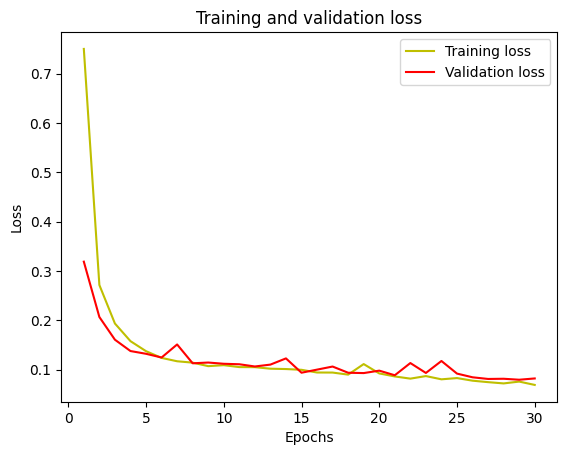

In [184]:
import matplotlib.pyplot as plt
import seaborn as sns

loss =cnn_model_history.history['loss']
val_loss =cnn_model_history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

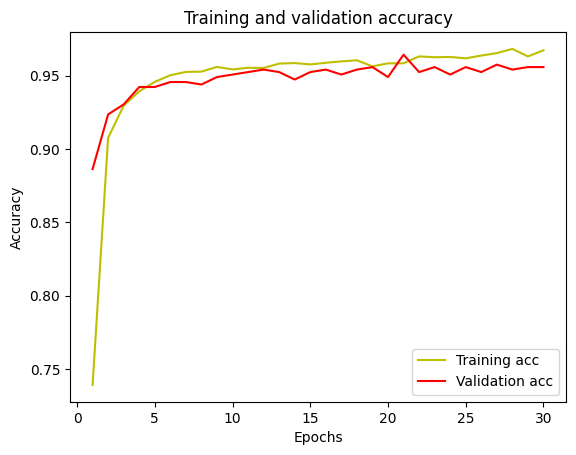

In [185]:
acc =cnn_model_history.history['accuracy']
val_acc =cnn_model_history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [186]:
import numpy as np, pandas as pd, tensorflow as tf
#2 LSTM
lstm_model = Sequential([
    LSTM(64, input_shape=(n_timesteps, n_features)),  # 128 timesteps, 9 features
    Dropout(0.5),                                     # 과적합 방지
    Dense(100, activation='relu'),
    Dense(n_outputs, activation='softmax')            # 클래스 수 6
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [187]:
from sklearn.preprocessing import StandardScaler

lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_48"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_276 (Dense)               │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_277 (Dense)               │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,050 (101.76 KB)

 Trainable params: 26,050 (101.76 KB)

 Non-trainable params: 0 (0.00 B)

In [188]:
lstm_model_history = lstm_model.fit(
    X_train, y_train_one_hot,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val_one_hot),
    verbose=1
)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.3815 - loss: 1.4727 - val_accuracy: 0.5581 - val_loss: 1.0319
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5788 - loss: 1.0219 - val_accuracy: 0.6506 - val_loss: 0.8362
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6727 - loss: 0.7661 - val_accuracy: 0.7383 - val_loss: 0.5721
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7294 - loss: 0.6158 - val_accuracy: 0.7417 - val_loss: 0.5338
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7725 - loss: 0.5194 - val_accuracy: 0.8199 - val_loss: 0.4431
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8286 - loss: 0.4207 - val_accuracy: 0.8953 - val_loss: 0.2803
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9081 - loss: 0.2897 - val_accuracy: 0.9109 - val_loss: 0.2038
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9034 - loss: 0.2752 - val_accuracy: 0.8613 - v

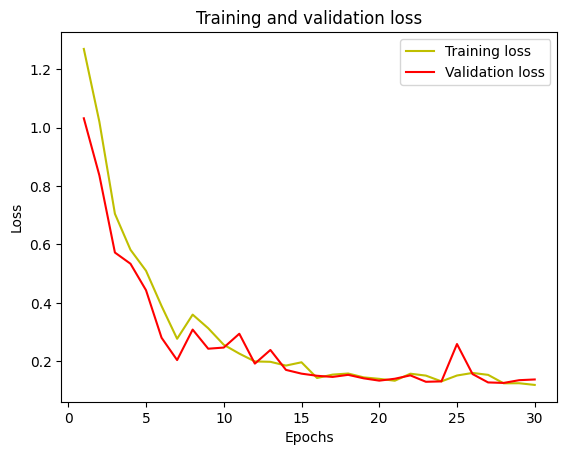

In [189]:
import matplotlib.pyplot as plt
import seaborn as sns

loss =lstm_model_history.history['loss']
val_loss =lstm_model_history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

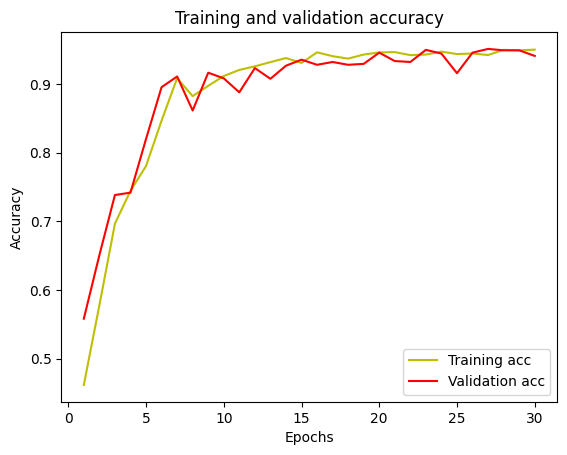

In [190]:
acc =lstm_model_history.history['accuracy']
val_acc =lstm_model_history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [191]:
#3 CNN + LSTM
cnn_lstm_model = Sequential([

    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(n_timesteps, n_features)),
    MaxPooling1D(pool_size=2),

    LSTM(64),

    Dense(100, activation='relu'),
    Dropout(0.5),
    Dense(n_outputs, activation='softmax')
])

cnn_lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

cnn_lstm_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_49"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_149 (Conv1D)             │ (None, 128, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_24 (MaxPooling1D) │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_278 (Dense)               │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_279 (Dense)               │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,922 (163.76 KB)

 Trainable params: 41,922 (163.76 KB)

 Non-trainable params: 0 (0.00 B)

In [192]:
cnn_lstm_model_history = cnn_lstm_model.fit(
    X_train, y_train_one_hot,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val_one_hot),
    verbose=1
)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4343 - loss: 1.3564 - val_accuracy: 0.5867 - val_loss: 0.9055
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7203 - loss: 0.6462 - val_accuracy: 0.8300 - val_loss: 0.4155
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8436 - loss: 0.4261 - val_accuracy: 0.8912 - val_loss: 0.2841
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8988 - loss: 0.2831 - val_accuracy: 0.9001 - val_loss: 0.2723
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9270 - loss: 0.2287 - val_accuracy: 0.9300 - val_loss: 0.1869
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9356 - loss: 0.1889 - val_accuracy: 0.9354 - val_loss: 0.1710
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9367 - loss: 0.1734 - val_accuracy: 0.9409 - val_loss: 0.1411
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9486 - loss: 0.1443 - val_accuracy: 0.9449 - val_loss

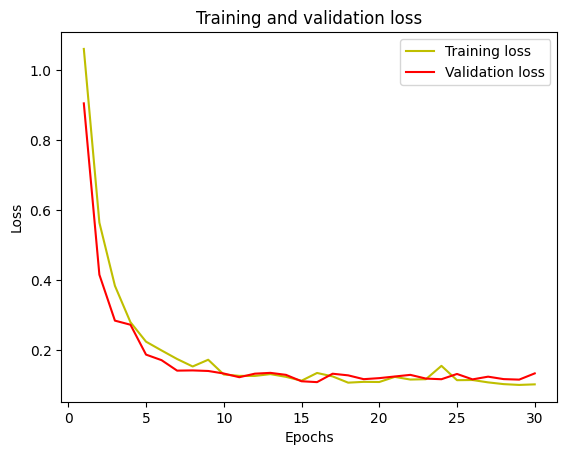

In [193]:
import matplotlib.pyplot as plt
import seaborn as sns

loss =cnn_lstm_model_history.history['loss']
val_loss =cnn_lstm_model_history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

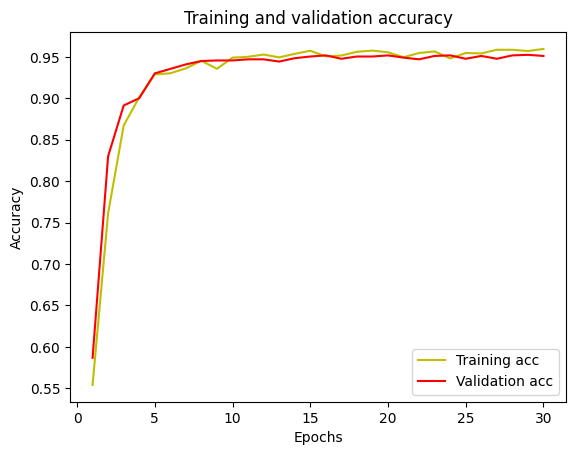

In [194]:
acc =cnn_lstm_model_history.history['accuracy']
val_acc =cnn_lstm_model_history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [195]:
import tensorflow as tf
from tensorflow.keras import layers, models, activations

#4 ResNet
class ResNetBlock(tf.keras.layers.Layer):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = layers.Conv1D(channels, 3, padding='same')
        self.bn1 = layers.BatchNormalization()
        self.conv2 = layers.Conv1D(channels, 3, padding='same')
        self.bn2 = layers.BatchNormalization()
        self.relu = layers.ReLU()

    def call(self, x, training=False):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out, training=training)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out, training=training)
        out = out + residual
        return self.relu(out)

In [196]:
inputs = Input(shape=(n_timesteps, n_features))

x = layers.Conv1D(64, 3, padding='same', activation='relu')(inputs)


x = ResNetBlock(64)(x)
x = ResNetBlock(64)(x)
x = ResNetBlock(64)(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(n_outputs, activation='softmax')(x)


res_model = Model(inputs, outputs)
res_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [197]:
res_model_history = res_model.fit(
    X_train,
    y_train_one_hot,
    epochs=30,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.8431 - loss: 0.4868 - val_accuracy: 0.3345 - val_loss: 2.4519
Epoch 2/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9475 - loss: 0.1532 - val_accuracy: 0.9423 - val_loss: 0.1587
Epoch 3/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9471 - loss: 0.1297 - val_accuracy: 0.9355 - val_loss: 0.1497
Epoch 4/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9442 - loss: 0.1371 - val_accuracy: 0.9491 - val_loss: 0.1032
Epoch 5/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9490 - loss: 0.1208 - val_accuracy: 0.9491 - val_loss: 0.1076
Epoch 6/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9495 - loss: 0.1153 - val_accuracy: 0.9542 - val_loss: 0.1244
Epoch 7/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9526 - loss: 0.1153 - val_accuracy: 0.9066 - val_loss: 0.1923
Epoch 8/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9497 - loss: 0.1141 - val_accuracy: 

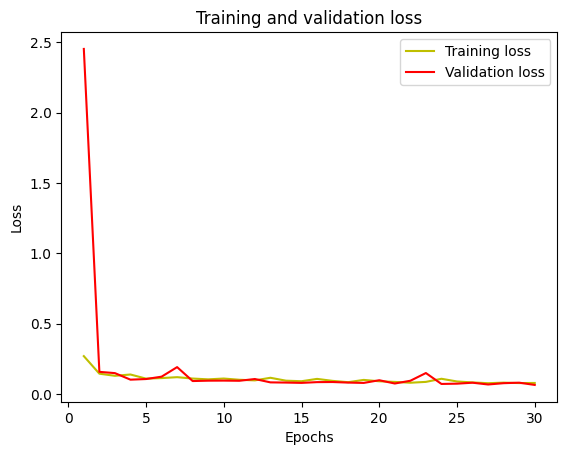

In [198]:
import matplotlib.pyplot as plt
import seaborn as sns

loss =res_model_history.history['loss']
val_loss =res_model_history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

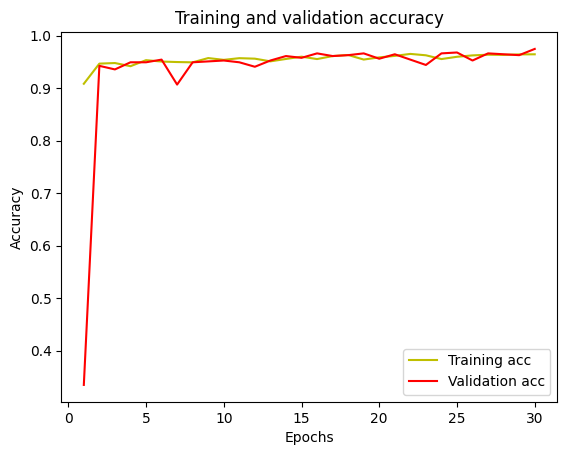

In [199]:
acc =res_model_history.history['accuracy']
val_acc =res_model_history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [200]:
#5 Transformer Encoder

# -----------------------------
# Multi-Head Self-Attention
# -----------------------------
class MultiHeadSelfAttention(tf.keras.layers.Layer):
    def __init__(self, dim, num_heads=4):
        super().__init__()
        assert dim % num_heads == 0, "hidden_dim must be divisible by num_heads"
        self.num_heads = num_heads
        self.head_dim = dim // num_heads

        self.query = layers.Dense(dim)
        self.key = layers.Dense(dim)
        self.value = layers.Dense(dim)
        self.out = layers.Dense(dim)

    def call(self, x):
        B = tf.shape(x)[0]
        N = tf.shape(x)[1]
        D = x.shape[-1]
        H = self.num_heads
        d = self.head_dim

        # Linear projections
        Q = tf.reshape(self.query(x), (B, N, H, d))
        K = tf.reshape(self.key(x), (B, N, H, d))
        V = tf.reshape(self.value(x), (B, N, H, d))

        Q = tf.transpose(Q, perm=[0, 2, 1, 3])  # (B, H, N, d)
        K = tf.transpose(K, perm=[0, 2, 1, 3])
        V = tf.transpose(V, perm=[0, 2, 1, 3])

        # Scaled Dot-Product Attention
        attn_score = tf.matmul(Q, K, transpose_b=True) / tf.sqrt(tf.cast(d, tf.float32))
        attn_weight = tf.nn.softmax(attn_score, axis=-1)
        attn_out = tf.matmul(attn_weight, V)  # (B, H, N, d)

        # Concat heads
        attn_out = tf.transpose(attn_out, perm=[0, 2, 1, 3])  # (B, N, H, d)
        attn_out = tf.reshape(attn_out, (B, N, D))  # (B, N, D)
        return self.out(attn_out)

# -----------------------------
# Transformer Encoder Layer
# -----------------------------
class CustomTransformerEncoderLayer(tf.keras.layers.Layer):
    def __init__(self, dim, num_heads=4, ff_dim=128, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadSelfAttention(dim, num_heads)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.ff = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(dim),
        ])
        self.dropout = layers.Dropout(dropout)

    def call(self, x, training=False):
        attn_out = self.attn(x)
        x = self.norm1(x + self.dropout(attn_out, training=training))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out, training=training))
        return x




In [201]:
inputs = tf.keras.Input(shape=(n_timesteps, n_features))
x = layers.Dense(64)(inputs)  # <== 입력 차원 9 → 64
x = CustomTransformerEncoderLayer(64)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(n_outputs, activation='softmax')(x)
trans_model = tf.keras.Model(inputs, outputs)
trans_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [202]:
trans_model_history = trans_model.fit(
    X_train,
    y_train_one_hot,
    epochs=30,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.6577 - loss: 0.8735 - val_accuracy: 0.9066 - val_loss: 0.2432
Epoch 2/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9136 - loss: 0.2358 - val_accuracy: 0.9287 - val_loss: 0.1834
Epoch 3/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9327 - loss: 0.1710 - val_accuracy: 0.9355 - val_loss: 0.1427
Epoch 4/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9370 - loss: 0.1538 - val_accuracy: 0.9440 - val_loss: 0.1177
Epoch 5/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9406 - loss: 0.1343 - val_accuracy: 0.9389 - val_loss: 0.1284
Epoch 6/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9462 - loss: 0.1289 - val_accuracy: 0.9423 - val_loss: 0.1363
Epoch 7/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9435 - loss: 0.1333 - val_accuracy: 0.9457 - val_loss: 0.1143
Epoch 8/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9507 - loss: 0.1187 - val_accuracy: 

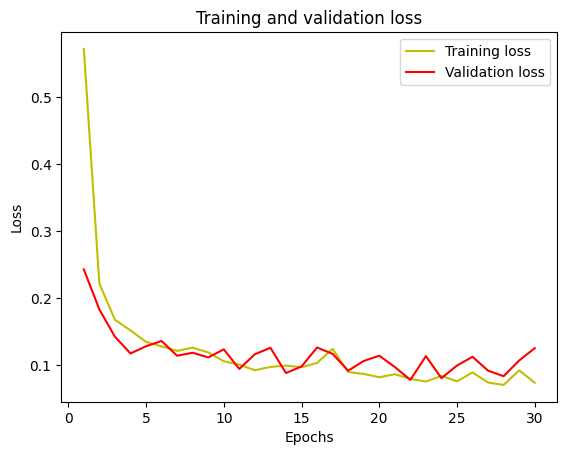

In [203]:
import matplotlib.pyplot as plt
import seaborn as sns

loss =trans_model_history.history['loss']
val_loss =trans_model_history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

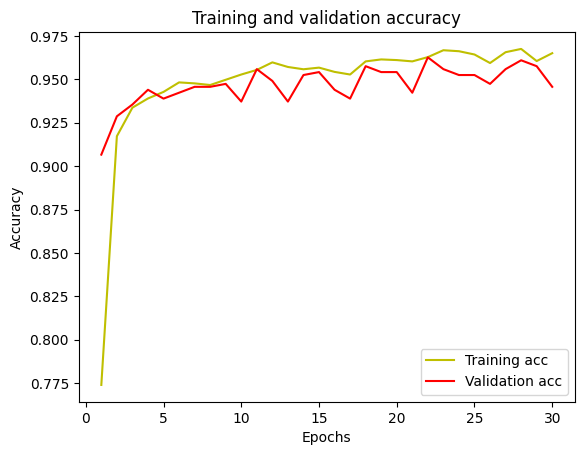

In [204]:
acc =trans_model_history.history['accuracy']
val_acc =trans_model_history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [205]:
#6 Resnet + Transformer Encoder
# -----------------------------
# 전체 모델: ResNet + Transformer + 분류기
# -----------------------------
class ResNetTransformerClassifier(tf.keras.Model):
    def __init__(self, input_dim, hidden_dim, num_classes,
                 num_resnet_blocks=2, num_transformer_layers=2,
                 num_heads=4, ff_dim=128):
        super().__init__()
        self.fc0 = layers.Dense(hidden_dim)

        self.resnet_blocks = [ResNetBlock(1) for _ in range(num_resnet_blocks)]

        self.transformer_layers = [
            CustomTransformerEncoderLayer(hidden_dim, num_heads, ff_dim)
            for _ in range(num_transformer_layers)
        ]

        self.fc_out = layers.Dense(num_classes, activation=None)

    def call(self, x, training=False):
        # (B, F) → (B, H)
        x = self.fc0(x)
        # (B, H) → (B, 1, H)
        for block in self.resnet_blocks:
            x = block(x, training=training)  # Conv1D용

        for layer in self.transformer_layers:
            x = layer(x, training=training)

        x = tf.reduce_mean(x, axis=1)  # timesteps 평균
        logits = self.fc_out(x)
        probs = tf.nn.softmax(logits, axis=-1)
        return logits

In [206]:
X_train_input = X_train  # (batch, 128, 9)
X_val_input   = X_val
testX_input   = testX
# 모델 생성 시 input_dim = n_features (9)
hidden_dim = 64
resnet_transformer_model = ResNetTransformerClassifier(
    input_dim=n_features,  # 9
    hidden_dim=hidden_dim,
    num_classes=n_outputs
)

resnet_transformer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)


In [207]:
resnet_transformer_history = resnet_transformer_model.fit(
    X_train_input, y_train_one_hot,
    validation_data=(X_val_input, y_val_one_hot),
    epochs=30,
    batch_size=64,
    verbose=1
)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 27s 120ms/step - accuracy: 0.4924 - loss: 1.1570 - val_accuracy: 0.4262 - val_loss: 2.7623
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7835 - loss: 0.5225 - val_accuracy: 0.6873 - val_loss: 0.7760
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8790 - loss: 0.3057 - val_accuracy: 0.8824 - val_loss: 0.2880
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9157 - loss: 0.2044 - val_accuracy: 0.9171 - val_loss: 0.2053
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9251 - loss: 0.1802 - val_accuracy: 0.9477 - val_loss: 0.1470
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9410 - loss: 0.1461 - val_accuracy: 0.9388 - val_loss: 0.1335
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9484 - loss: 0.1250 - val_accuracy: 0.9402 - val_loss: 0.1512
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9384 - loss: 0.1452 - val_accuracy: 0.9395 -

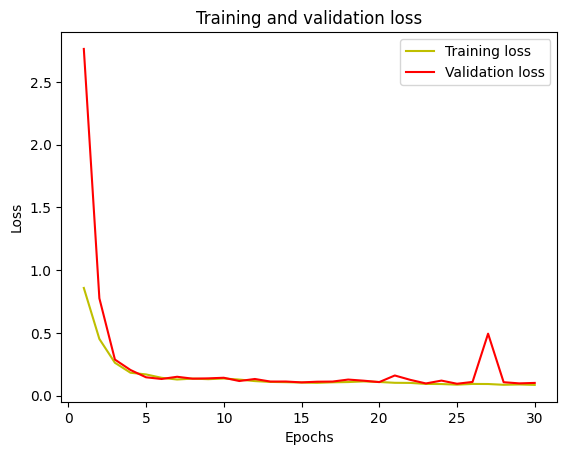

In [208]:
import matplotlib.pyplot as plt
import seaborn as sns

loss =resnet_transformer_history.history['loss']
val_loss =resnet_transformer_history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

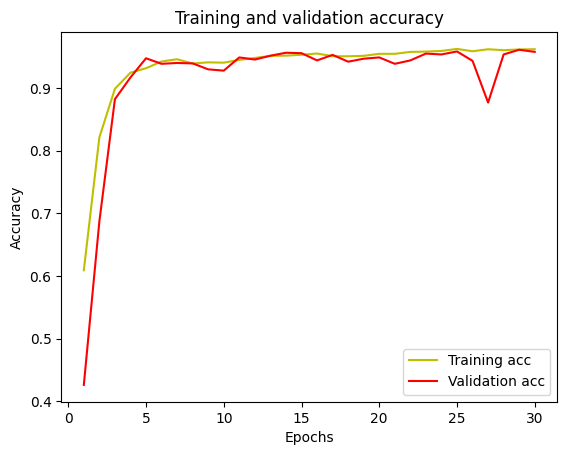

In [209]:
acc =resnet_transformer_history.history['accuracy']
val_acc =resnet_transformer_history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()